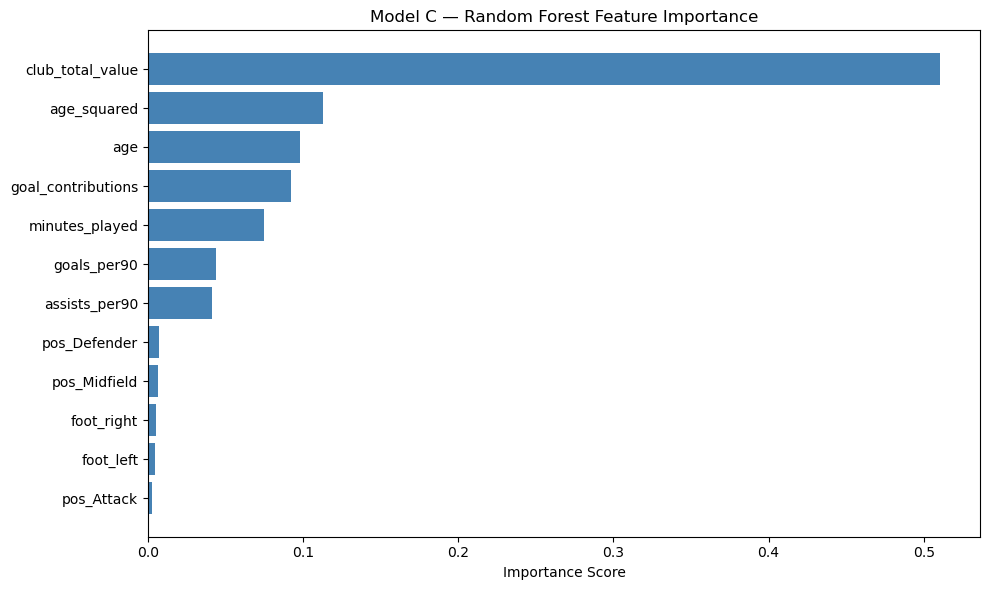

Saved: eval_feature_importance.png

── Feature Importance ──
               feature  importance
6     club_total_value    0.510725
5          age_squared    0.112735
4                  age    0.098214
2   goal_contributions    0.092001
3       minutes_played    0.074806
0          goals_per90    0.044144
1        assists_per90    0.041322
8         pos_Defender    0.006983
9         pos_Midfield    0.006379
11          foot_right    0.005257
10           foot_left    0.004664
7           pos_Attack    0.002770


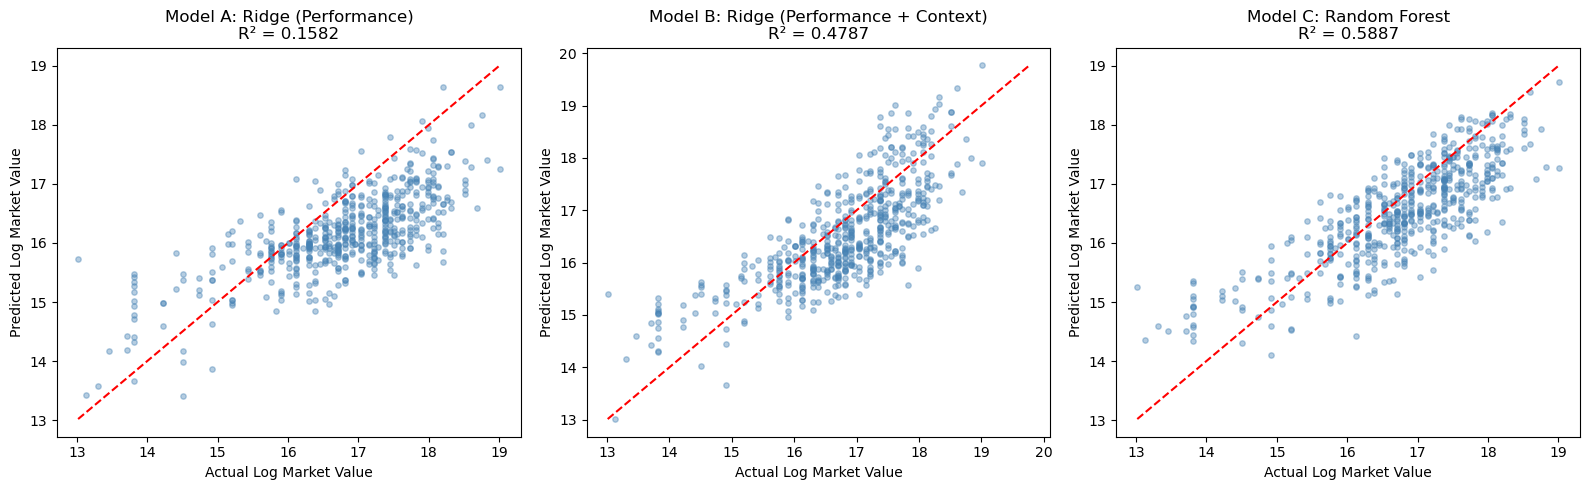

Saved: eval_predicted_vs_actual.png


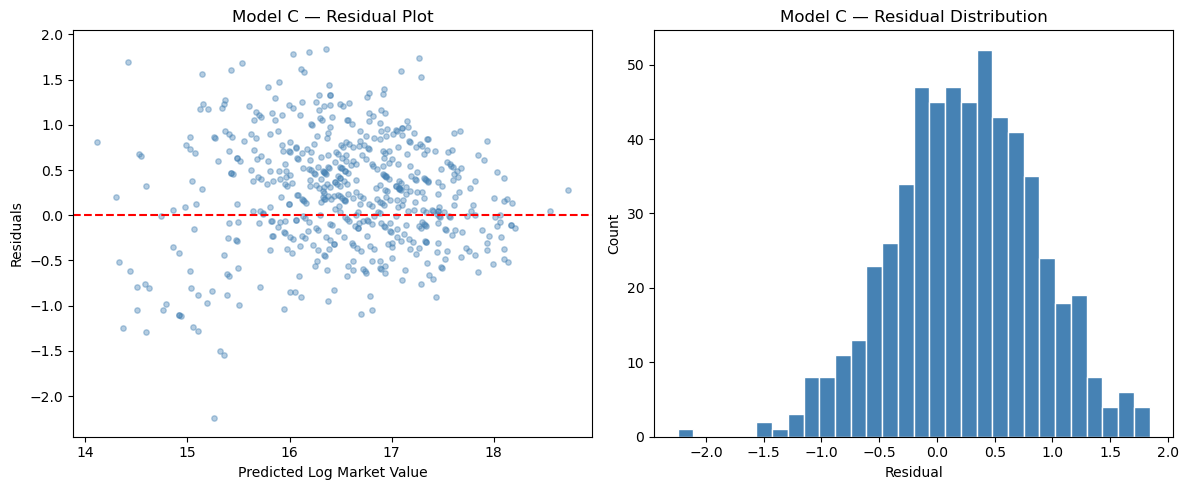

Saved: eval_residuals.png

── Top 10 Most Overvalued Players (2023-2024) ──
      player_id  season     actual_mv  predicted_mv  overvaluation_index
2978     258004    2024  8.000000e+07  1.270293e+07             1.840194
3544     444523    2024  6.500000e+07  1.070679e+07             1.803509
2972     257455    2024  5.500000e+07  9.227430e+06             1.785153
3495     418560    2024  1.800000e+08  3.149230e+07             1.743214
3765     649452    2023  1.000000e+07  1.828970e+06             1.698832
2294     139208    2024  3.000000e+07  5.592279e+06             1.679810
1763      88755    2024  5.000000e+07  9.947726e+06             1.614679
2414     157509    2024  2.500000e+07  4.995867e+06             1.610265
3348     357565    2024  1.300000e+08  2.645414e+07             1.592122
2940     251664    2024  5.000000e+07  1.023058e+07             1.586642

── Top 10 Most Undervalued Players (2023-2024) ──
      player_id  season  actual_mv  predicted_mv  overvaluation_index


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import r2_score, mean_squared_error

# Load data and models
df         = pd.read_csv('../thesis_dataset/engineered_dataset.csv')
pipeline_A = joblib.load('../thesis_dataset/model_A.pkl')
pipeline_B = joblib.load('../thesis_dataset/model_B.pkl')
pipeline_C = joblib.load('../thesis_dataset/model_C.pkl')

TEST_SEASONS = [2023, 2024]

features_A = [
    'goals_per90', 'assists_per90', 'goal_contributions',
    'minutes_played', 'age', 'age_squared'
]

features_B = features_A + [
    'club_total_value', 'pos_Attack', 'pos_Defender',
    'pos_Midfield', 'foot_left', 'foot_right'
]

def temporal_split(df, features, target='log_market_value'):
    model_df = df[features + [target, 'season']].dropna()
    train = model_df[~model_df['season'].isin(TEST_SEASONS)]
    test  = model_df[ model_df['season'].isin(TEST_SEASONS)]
    return (train[features], test[features],
            train[target],  test[target])

_, X_test_A, _, y_test_A = temporal_split(df, features_A)
_, X_test_B, _, y_test_B = temporal_split(df, features_B)
_, X_test_C, _, y_test_C = temporal_split(df, features_B)

y_pred_A = pipeline_A.predict(X_test_A)
y_pred_B = pipeline_B.predict(X_test_B)
y_pred_C = pipeline_C.predict(X_test_C)

# 1. Feature Importance — Model C
rf_model = pipeline_C.named_steps['model']

importance_df = pd.DataFrame({
    'feature':    features_B,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df['feature'], importance_df['importance'],
        color='steelblue')
ax.set_title('Model C — Random Forest Feature Importance')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../thesis_dataset/eval_feature_importance.png', dpi=150)
plt.show()
print("Saved: eval_feature_importance.png")
print("\n── Feature Importance ──")
print(importance_df.sort_values('importance', ascending=False))

# 2. Predicted vs Actual — All Models
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, y_test, y_pred, title in zip(
    axes,
    [y_test_A, y_test_B, y_test_C],
    [y_pred_A, y_pred_B, y_pred_C],
    ['Model A: Ridge (Performance)', 
     'Model B: Ridge (Performance + Context)',
     'Model C: Random Forest']
):
    ax.scatter(y_test, y_pred, alpha=0.4, s=15, color='steelblue')
    mn = min(y_test.min(), y_pred.min())
    mx = max(y_test.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5)
    ax.set_xlabel('Actual Log Market Value')
    ax.set_ylabel('Predicted Log Market Value')
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f'{title}\nR² = {r2:.4f}')

plt.tight_layout()
plt.savefig('../thesis_dataset/eval_predicted_vs_actual.png', dpi=150)
plt.show()
print("Saved: eval_predicted_vs_actual.png")

# 3. Residual Analysis — Model C
residuals = y_test_C.values - y_pred_C

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_pred_C, residuals, alpha=0.4, 
                s=15, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Log Market Value')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Model C — Residual Plot')

axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Model C — Residual Distribution')

plt.tight_layout()
plt.savefig('../thesis_dataset/eval_residuals.png', dpi=150)
plt.show()
print("Saved: eval_residuals.png")

# 4. Overvaluation Index
# Identifies players whose actual market value deviates
# significantly from model predictions.
# Positive = overvalued, Negative = undervalued

test_df = df[features_B + ['log_market_value', 'season', 
                             'player_id']].dropna()
test_df = test_df[test_df['season'].isin(TEST_SEASONS)].copy()
test_df['predicted_log_mv'] = pipeline_C.predict(test_df[features_B])
test_df['overvaluation_index'] = (
    test_df['log_market_value'] - test_df['predicted_log_mv']
)

# Convert back to euros for interpretability
test_df['actual_mv']    = np.exp(test_df['log_market_value'])
test_df['predicted_mv'] = np.exp(test_df['predicted_log_mv'])
test_df['mv_difference'] = test_df['actual_mv'] - test_df['predicted_mv']

print("\n── Top 10 Most Overvalued Players (2023-2024) ──")
print(
    test_df.nlargest(10, 'overvaluation_index')[
        ['player_id', 'season', 'actual_mv', 
         'predicted_mv', 'overvaluation_index']
    ].to_string()
)

print("\n── Top 10 Most Undervalued Players (2023-2024) ──")
print(
    test_df.nsmallest(10, 'overvaluation_index')[
        ['player_id', 'season', 'actual_mv', 
         'predicted_mv', 'overvaluation_index']
    ].to_string()
)

# 5. Final Results Summary
print("\n\n══════════════════════════════════════════════════════")
print("  FINAL MODEL EVALUATION SUMMARY")
print("══════════════════════════════════════════════════════")
print(f"{'Model':<10} {'Algorithm':<20} {'R²':>8} {'RMSE':>8}")
print(f"{'─'*10} {'─'*20} {'─'*8} {'─'*8}")
for label, y_t, y_p, algo in [
    ('A', y_test_A, y_pred_A, 'Ridge (Perf only)'),
    ('B', y_test_B, y_pred_B, 'Ridge (Perf+Ctx)'),
    ('C', y_test_C, y_pred_C, 'Random Forest'),
]:
    r2   = r2_score(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    print(f"{label:<10} {algo:<20} {r2:>8.4f} {rmse:>8.4f}")

print("\nKey finding: club_total_value is the dominant predictor")
print(f"(importance: {rf_model.feature_importances_[features_B.index('club_total_value')]:.4f})")
print("\nConclusion: Contextual factors explain market value")
print("significantly more than performance metrics alone.")